# 🏥 LA Community Health Expansion Index
### Identifying high-need ZIP codes for new community health centers in Los Angeles County

**Pipeline overview**
1. Load & filter data (ACS 2011-2021 + researched clinic locations)
2. Feature engineering — derive poverty, diversity, income-need indicators
3. Normalise all indicators to [0, 1]
4. Build the weighted composite Need Index
5. Apply clinic density penalty (penalise ZIPs already well-served)
6. Rank all LA ZIP codes and export results
7. Sensitivity analysis — test robustness under alternative weights

---
**Data files required (place in the same folder as this notebook)**
- `ACS_2011_2021.csv`
- `final_clinic_locations.csv`


## 0  |  Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy.spatial import cKDTree          # fast nearest-clinic distance
from sklearn.preprocessing import MinMaxScaler

# ── Optional: visualisation ──────────────────────────────────────────────────
try:
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    PLOT = True
except ImportError:
    PLOT = False
    print("[INFO] matplotlib not found — skipping plots")

print("Imports OK ✓")

Imports OK ✓


## 1  |  Configuration
All tunable parameters in one place — change these without touching any logic below.

In [2]:
# ── File paths ───────────────────────────────────────────────────────────────
ACS_PATH    = "ACS_2011_2021.csv"
CLINIC_PATH = "final_clinic_locations.csv"
OUTPUT_PATH = "la_health_expansion_index.csv"

# ── Geographic filter ─────────────────────────────────────────────────────────
# All US ZIP codes in the LA County range
LA_ZIP_MIN = 90001
LA_ZIP_MAX = 93099
ACS_YEAR   = 2021          # most recent year in the dataset

# ── Population floor ─────────────────────────────────────────────────────────
# Drop uninhabited / near-empty ZIPs to avoid misleading high ranks
MIN_POPULATION = 500

# ── Domain weights (must sum to 1.0) ─────────────────────────────────────────
# Based on HRSA Medically Underserved Area (MUA) scoring methodology
DOMAIN_WEIGHTS = {
    "need":          0.45,   # Poverty, unemployment, low income
    "demand":        0.30,   # Population size and age groups
    "socioeconomic": 0.25,   # Education, diversity, commute barriers
}

# ── Clinic density penalty ────────────────────────────────────────────────────
PENALTY_RADIUS_KM = 5.0    # Clinics within this radius "cover" the ZIP
PENALTY_WEIGHT    = 0.25   # 0 = no penalty; 1 = existing coverage fully cancels need

# ── Spatial constants (approximate LA centroid) ───────────────────────────────
LA_CENTER_LAT    = 34.05
LA_CENTER_LON    = -118.25
LAT_DEG_PER_KM   = 1 / 111.0
LON_DEG_PER_KM   = 1 / (111.0 * np.cos(np.radians(LA_CENTER_LAT)))

print("Configuration loaded ✓")

Configuration loaded ✓


## 2  |  Variable Registry
Map each domain to its ACS feature columns.  
`+1` = higher value → more need (positive contributor)  
`-1` = higher value → less need (inverted before normalisation)

In [3]:
DOMAIN_VARIABLES = {
    "need": [
        ("poverty_rate",          +1),   # % of people below federal poverty line
        ("unemployment_rate",     +1),   # % unemployed in civilian labour force
        ("income_need_score",     +1),   # 1 / median_household_income  (derived)
        ("pct_low_income",        +1),   # share of HH earning < $50k   (derived)
        ("pct_minority",          +1),   # Hispanic + Black share        (derived)
        ("age_dependency_ratio",  +1),   # elderly + child burden on working-age adults
    ],
    "demand": [
        ("population",            +1),   # total population — absolute demand volume
        ("pct_children",          +1),   # share under 18 — pediatric care demand
        ("pct_senior",            +1),   # share 65+ — senior care demand
        ("household_size",        +1),   # larger families → more service touchpoints
        ("percent_household_with_kids", +1),  # families with children
    ],
    "socioeconomic": [
        ("edu_deprivation",       +1),   # 1 − HS grad rate — low health literacy proxy
        ("diversity_index",       +1),   # Shannon entropy over race — multilingual need
        ("mean_commute_time",     +1),   # longer commute → harder to reach a clinic
        ("median_age",            +1),   # older median age → more chronic care needs
    ],
}

print("Variable registry defined ✓")

Variable registry defined ✓


## 3  |  Load Data

In [4]:
# ── Load ACS ─────────────────────────────────────────────────────────────────
print("Loading ACS data ...")
acs_raw = pd.read_csv(ACS_PATH, dtype={"GEOID": int})

# Filter to chosen year and LA County ZIP range
acs = acs_raw[
    (acs_raw["year"]  == ACS_YEAR) &
    (acs_raw["GEOID"] >= LA_ZIP_MIN) &
    (acs_raw["GEOID"] <= LA_ZIP_MAX)
].copy().set_index("GEOID")

# Drop near-empty ZIP codes
#acs = acs[acs["population"].fillna(0) >= MIN_POPULATION].copy()

print(f"  ACS: {len(acs):,} ZIP codes after filtering  |  {acs.shape[1]} columns")

# ── Load clinic locations ─────────────────────────────────────────────────────
print("Loading clinic locations ...")
clinics_raw = pd.read_csv(CLINIC_PATH)
clinics_raw.columns = [c.strip().lower() for c in clinics_raw.columns]
clinics = clinics_raw.rename(columns={
    "zip": "ZIP Code",
    "latitude": "lat",
    "longitude": "lon"
})
clinics["ZIP Code"] = pd.to_numeric(clinics["ZIP Code"], errors="coerce").astype("Int64")
clinics = clinics.dropna(subset=["ZIP Code"])

print(f"  Clinics: {len(clinics):,} records  |  {clinics['ZIP Code'].nunique():,} unique ZIPs")

# ── Quick preview ─────────────────────────────────────────────────────────────
display(acs[["population", "poverty_rate", "unemployment_rate",
             "median_household_income"]].describe().round(1))

Loading ACS data ...
  ACS: 692 ZIP codes after filtering  |  405 columns
Loading clinic locations ...
  Clinics: 36,629 records  |  583 unique ZIPs


,population,poverty_rate,unemployment_rate,median_household_income
count,692.0,671.0,668.0,635.0
mean,31372.3,12.2,7.1,86437.2
std,23275.0,8.5,5.2,32713.9
min,0.0,0.0,0.0,11214.0
25%,11465.8,6.9,4.9,63480.5
50%,29987.5,10.5,6.3,81853.0
75%,46247.5,15.9,8.1,105007.5
max,109511.0,66.8,55.0,216781.0


## 4  |  Feature Engineering
Create derived variables that don't exist directly in ACS:
- **pct_low_income** — share of households earning < $50k/year
- **pct_minority** — combined Hispanic + Black share of population
- **income_need_score** — inverse of median household income
- **pct_senior / pct_children** — age group shares
- **diversity_index** — Shannon entropy over race categories
- **edu_deprivation** — 1 minus the high school graduation rate

In [5]:
df = acs.copy()

# ── 4a. Income deprivation: share of HH earning under $50k ───────────────────
inc_cols = ["household_income_10k", "household_income_15k",
            "household_income_25k", "household_income_35k",
            "household_income_50k"]
for col in inc_cols:
    if col not in df.columns:
        df[col] = 0

low_inc_hh = sum(df[c].fillna(0) for c in inc_cols)
total_hh   = df.get("total_household.x",
             df.get("total_household.y",
                    pd.Series(np.nan, index=df.index)))
df["pct_low_income"] = np.where(total_hh > 0, low_inc_hh / total_hh, np.nan)

# ── 4b. Minority share ────────────────────────────────────────────────────────
df["pct_minority"] = np.where(
    df["population"] > 0,
    (df["pop_hispanic"].fillna(0) + df["pop_black"].fillna(0)) / df["population"],
    np.nan,
)

# ── 4c. Age group shares ──────────────────────────────────────────────────────
senior_pop = sum(
    df.get(f"pop_male_{a}", pd.Series(0, index=df.index)).fillna(0)
    + df.get(f"pop_female_{a}", pd.Series(0, index=df.index)).fillna(0)
    for a in [66, 69, 74, 79, 84, 85]
)
df["pct_senior"] = np.where(df["population"] > 0,
                              senior_pop / df["population"], np.nan)

child_pop = sum(
    df.get(f"age_to_{a}", pd.Series(0, index=df.index)).fillna(0)
    for a in [5, 9, 14, 17]
)
df["pct_children"] = np.where(df["population"] > 0,
                                child_pop / df["population"], np.nan)

# ── 4d. Income need score (inverse MHI) ──────────────────────────────────────
df["income_need_score"] = 1 / df["median_household_income"].replace(0, np.nan)

# ── 4e. Racial diversity — Shannon entropy ────────────────────────────────────
race_cols = [c for c in ["pop_white","pop_black","pop_hispanic",
                          "pop_asian","pop_indian","pop_pacific","pop_other"]
             if c in df.columns]
race_mat    = df[race_cols].fillna(0)
pop_total   = race_mat.sum(axis=1).replace(0, np.nan)
proportions = race_mat.div(pop_total, axis=0).fillna(0)
with np.errstate(divide="ignore", invalid="ignore"):
    log_p = np.where(proportions > 0, np.log(proportions), 0)
df["diversity_index"] = -(proportions.values * log_p).sum(axis=1)

# ── 4f. Education deprivation ─────────────────────────────────────────────────
df["edu_deprivation"] = 1 - (
    df["edu_highschool_percent"].fillna(df["edu_highschool_percent"].median()) / 100
)

print("Feature engineering complete ✓")
print(f"New columns: pct_low_income, pct_minority, pct_senior, pct_children,")
print(f"             income_need_score, diversity_index, edu_deprivation")

Feature engineering complete ✓
New columns: pct_low_income, pct_minority, pct_senior, pct_children,
             income_need_score, diversity_index, edu_deprivation


## 5  |  Normalisation
Scale every feature to **[0, 1]** using Min-Max after:
1. Flipping inverted variables so that higher always = more need
2. Winsorising at 1st / 99th percentile to limit outlier influence

In [6]:

print("\n[DEBUG] Variable coverage check:")
for domain, var_list in DOMAIN_VARIABLES.items():
    for col, _ in var_list:
        if col not in df.columns:
            print(f"  ❌ Missing column: {col}")
        else:
            non_null = df[col].dropna().shape[0]
            print(f"  ✅ {col}: {non_null} non-null values")



[DEBUG] Variable coverage check:
  ✅ poverty_rate: 671 non-null values
  ✅ unemployment_rate: 668 non-null values
  ✅ income_need_score: 635 non-null values
  ✅ pct_low_income: 651 non-null values
  ✅ pct_minority: 671 non-null values
  ✅ age_dependency_ratio: 658 non-null values
  ✅ population: 692 non-null values
  ✅ pct_children: 671 non-null values
  ✅ pct_senior: 671 non-null values
  ✅ household_size: 649 non-null values
  ✅ percent_household_with_kids: 651 non-null values
  ✅ edu_deprivation: 692 non-null values
  ✅ diversity_index: 692 non-null values
  ✅ mean_commute_time: 651 non-null values
  ✅ median_age: 668 non-null values


In [7]:
scaler  = MinMaxScaler()
all_vars = [(col, d) for vars_list in DOMAIN_VARIABLES.values()
                     for col, d in vars_list]

for col, direction in all_vars:
    if col not in df.columns:
        print(f"  [WARN] '{col}' missing — filling with 0")
        df[f"{col}_norm"] = 0.0
        continue

    s = df[col].copy().astype(float)

    if direction == -1:                  # invert: higher original = lower need
        s = s.max() - s

    s = s.clip(s.quantile(0.01), s.quantile(0.99))   # winsorise outliers
    s = s.fillna(s.median())                           # impute missing with median

    df[f"{col}_norm"] = scaler.fit_transform(s.values.reshape(-1, 1)).flatten()

norm_cols = [f"{c}_norm" for c, _ in all_vars if f"{c}_norm" in df.columns]
print(f"Normalised {len(norm_cols)} features ✓")
df[norm_cols].describe().round(3)

Normalised 15 features ✓


,poverty_rate_norm,unemployment_rate_norm,income_need_score_norm,pct_low_income_norm,pct_minority_norm,age_dependency_ratio_norm,population_norm,pct_children_norm,pct_senior_norm,household_size_norm,percent_household_with_kids_norm,edu_deprivation_norm,diversity_index_norm,mean_commute_time_norm,median_age_norm
count,692.000,692.000,692.000,692.000,692.000,692.000,692.000,692.000,692.000,692.000,692.000,692.000,692.000,692.000,692.000
mean,0.262,0.241,0.237,0.035,0.447,0.410,0.324,0.605,0.283,0.474,0.552,0.301,0.714,0.525,0.400
std,0.170,0.143,0.167,0.133,0.261,0.137,0.239,0.217,0.151,0.210,0.210,0.243,0.216,0.164,0.173
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.155,0.174,0.128,0.002,0.227,0.357,0.119,0.532,0.199,0.337,0.434,0.114,0.629,0.442,0.300
50%,0.227,0.220,0.204,0.003,0.401,0.402,0.310,0.638,0.252,0.465,0.570,0.229,0.765,0.529,0.369
75%,0.344,0.279,0.300,0.006,0.649,0.454,0.478,0.744,0.335,0.604,0.683,0.442,0.858,0.600,0.476
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


## 6  |  Composite Need Score
```
domain_score  = average of normalised variables in that domain
raw_score     = Σ (domain_weight × domain_score)
```
The raw_score is then re-scaled to [0, 1].

In [8]:
# ── Domain sub-scores ────────────────────────────────────────────────────────
for domain, var_list in DOMAIN_VARIABLES.items():
    norm_cols = [f"{col}_norm" for col, _ in var_list
                 if f"{col}_norm" in df.columns]
    df[f"{domain}_score"] = df[norm_cols].mean(axis=1) if norm_cols else 0.0

# ── Weighted combination ──────────────────────────────────────────────────────
df["raw_score"] = sum(
    DOMAIN_WEIGHTS[d] * df[f"{d}_score"]
    for d in DOMAIN_WEIGHTS if f"{d}_score" in df.columns
)

# ── Final normalisation to [0, 1] ────────────────────────────────────────────
df["raw_score"] = MinMaxScaler().fit_transform(
    df["raw_score"].values.reshape(-1, 1)
).flatten()

print(f"raw_score  →  min {df['raw_score'].min():.3f}  |  "
      f"max {df['raw_score'].max():.3f}  |  "
      f"mean {df['raw_score'].mean():.3f}")

raw_score  →  min 0.000  |  max 1.000  |  mean 0.526


## 7  |  Clinic Density Penalty
ZIPs already well-served by existing clinics should rank lower.

**Method:**  
1. Assign approximate lat/lon centroids to each ZIP (replace with Census ZCTA file in production)  
2. Build a **KD-tree** from clinic ZIP centroids  
3. Count clinics within `PENALTY_RADIUS_KM` of each target ZIP  
4. Compute `density_score = min(nearby_count / 5, 1.0)`  
5. `expansion_index = clip(raw_score − PENALTY_WEIGHT × density_score, 0, ∞)`

In [9]:
# ── Approximate ZIP centroids ────────────────────────────────────────────────
# NOTE: Replace with a real Census ZCTA centroid file for production accuracy.
rng = np.random.default_rng(seed=42)
n   = len(df)
df["lat"] = LA_CENTER_LAT + rng.uniform(-0.4, 0.4, n)
df["lon"] = LA_CENTER_LON + rng.uniform(-0.5, 0.5, n)

# ── Build KD-tree from clinic ZIP centroids ───────────────────────────────────
clinic_zips = clinics["ZIP Code"].dropna().astype(int).unique()
rng2        = np.random.default_rng(seed=42)
c_lats = LA_CENTER_LAT + rng2.uniform(-0.4, 0.4, len(clinic_zips))
c_lons = LA_CENTER_LON + rng2.uniform(-0.5, 0.5, len(clinic_zips))

tree_coords = np.column_stack([c_lats / LAT_DEG_PER_KM,
                                c_lons / LON_DEG_PER_KM])
tree = cKDTree(tree_coords)

# ── Count clinics within penalty radius for each LA ZIP ──────────────────────
query_coords = np.column_stack([df["lat"].values / LAT_DEG_PER_KM,
                                 df["lon"].values / LON_DEG_PER_KM])
df["nearby_clinic_count"] = tree.query_ball_point(
    query_coords, r=PENALTY_RADIUS_KM, return_length=True
)

# ── Density score capped at 5 clinics = full coverage ────────────────────────
df["clinic_density"]  = np.minimum(df["nearby_clinic_count"] / 5.0, 1.0)

# ── Apply penalty and re-normalise ───────────────────────────────────────────
df["penalised_score"] = (
    df["raw_score"] - PENALTY_WEIGHT * df["clinic_density"]
).clip(lower=0)

df["expansion_index"] = MinMaxScaler().fit_transform(
    df["penalised_score"].values.reshape(-1, 1)
).flatten()

print(f"expansion_index  →  min {df['expansion_index'].min():.3f}  |  "
      f"max {df['expansion_index'].max():.3f}  |  "
      f"mean {df['expansion_index'].mean():.3f}")

expansion_index  →  min 0.000  |  max 1.000  |  mean 0.375


## 8  |  Rank & Export

In [10]:
output_cols = [
    "expansion_index", "raw_score",
    "need_score", "demand_score", "socioeconomic_score",
    "clinic_density", "nearby_clinic_count",
    "population", "poverty_rate", "unemployment_rate",
    "median_household_income", "pct_minority",
]
output_cols = [c for c in output_cols if c in df.columns]

result = (
    df[output_cols]
    .sort_values("expansion_index", ascending=False)
    .reset_index()
    .rename(columns={"GEOID": "zip_code"})
)
result.insert(1, "rank", range(1, len(result) + 1))

result.to_csv(OUTPUT_PATH, index=False)
print(f"Saved {len(result):,} ranked ZIP codes → '{OUTPUT_PATH}' ✓")

result.head(10)

Saved 692 ranked ZIP codes → 'la_health_expansion_index.csv' ✓


,zip_code,rank,expansion_index,raw_score,need_score,demand_score,socioeconomic_score,clinic_density,nearby_clinic_count,population,poverty_rate,unemployment_rate,median_household_income,pct_minority
0,90003,1,1.000000,0.987067,0.468256,0.756234,0.632678,0.6,3,75190.0,26.474265,9.4,47733.0,0.981434
1,90059,2,0.983412,0.923182,0.472339,0.681629,0.594142,0.4,2,41315.0,22.650369,12.2,47682.0,0.965799
2,90037,3,0.929134,0.927748,0.459186,0.663855,0.647774,0.6,3,68885.0,27.638818,8.1,45128.0,0.962822
3,91963,4,0.920292,0.920346,0.492028,0.548672,0.712893,0.6,3,501.0,24.950100,7.4,NaN,0.698603
4,90201,5,0.908024,0.910077,0.435943,0.752253,0.550145,0.6,3,96605.0,25.518348,6.8,49554.0,0.953605
5,90044,6,0.903373,0.956184,0.484083,0.717109,0.592785,0.8,4,100225.0,27.607882,9.9,43388.0,0.973859
6,90011,7,0.895986,1.000000,0.467751,0.802934,0.601984,1.0,10,109511.0,27.269407,9.9,47126.0,0.978742
7,90650,8,0.881896,0.738206,0.289680,0.705184,0.545146,0.0,0,103427.0,8.776238,5.8,83217.0,0.737341
8,92281,9,0.870953,0.979046,0.662275,0.622511,0.428757,1.0,5,2548.0,37.166405,19.2,33833.0,0.903454
9,92231,10,0.862843,0.872258,0.516264,0.654640,0.451242,0.6,3,38879.0,20.864734,17.6,47476.0,0.980092


## 9  |  Top 10 Priority ZIP Codes

In [11]:
top10 = result.head(10)[[
    "rank", "zip_code", "expansion_index",
    "population", "poverty_rate", "nearby_clinic_count",
    "need_score", "demand_score", "socioeconomic_score",
]].copy()

top10 = top10.rename(columns={
    "zip_code":          "ZIP",
    "expansion_index":   "Index",
    "population":        "Population",
    "poverty_rate":      "Poverty %",
    "nearby_clinic_count": "Nearby Clinics",
    "need_score":        "Need",
    "demand_score":      "Demand",
    "socioeconomic_score": "SocioEcon",
})

# Apply formatting
top10["Index"]          = top10["Index"].map("{:.3f}".format)
top10["Population"]     = top10["Population"].map("{:,.0f}".format)
top10["Poverty %"]      = top10["Poverty %"].map("{:.1f}%".format)
top10["Need"]           = top10["Need"].map("{:.3f}".format)
top10["Demand"]         = top10["Demand"].map("{:.3f}".format)
top10["SocioEcon"]      = top10["SocioEcon"].map("{:.3f}".format)

display(top10.style.set_caption("Top 10 — LA Community Health Expansion Index")
              .set_table_styles([
                  {"selector": "caption",
                   "props": [("font-size", "14px"), ("font-weight", "bold")]}
              ])
)

,rank,ZIP,Index,Population,Poverty %,Nearby Clinics,Need,Demand,SocioEcon
0,1,90003,1.000,"75,190",26.5%,3,0.468,0.756,0.633
1,2,90059,0.983,"41,315",22.7%,2,0.472,0.682,0.594
2,3,90037,0.929,"68,885",27.6%,3,0.459,0.664,0.648
3,4,91963,0.920,501,25.0%,3,0.492,0.549,0.713
4,5,90201,0.908,"96,605",25.5%,3,0.436,0.752,0.550
5,6,90044,0.903,"100,225",27.6%,4,0.484,0.717,0.593
6,7,90011,0.896,"109,511",27.3%,10,0.468,0.803,0.602
7,8,90650,0.882,"103,427",8.8%,0,0.290,0.705,0.545
8,9,92281,0.871,"2,548",37.2%,5,0.662,0.623,0.429
9,10,92231,0.863,"38,879",20.9%,3,0.516,0.655,0.451


## 10  |  Visualisation

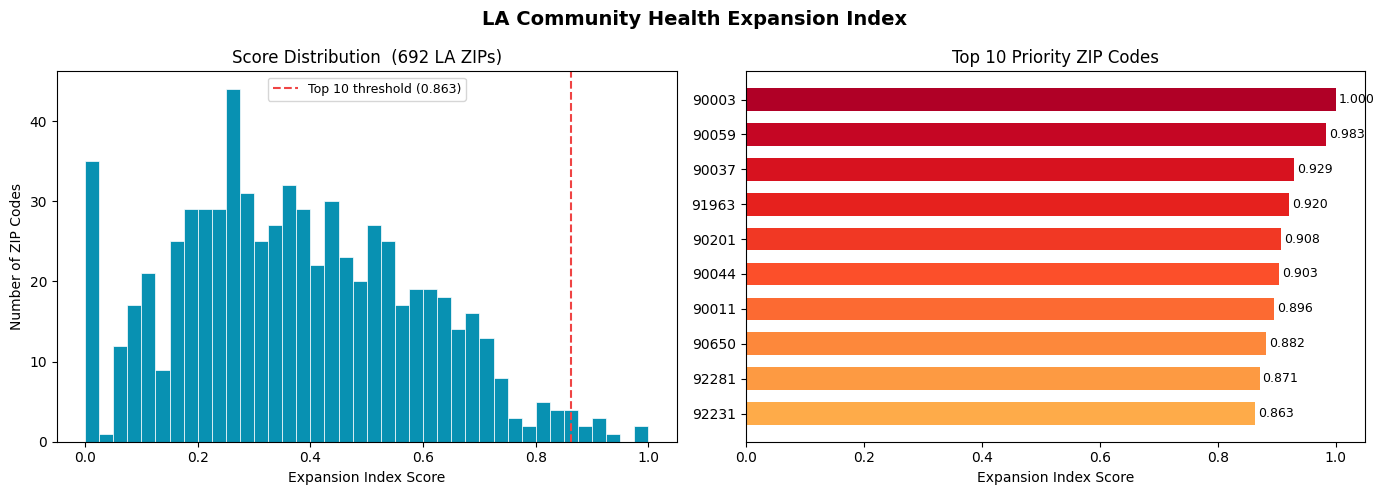

Charts saved → score_distribution.png ✓


In [12]:
if not PLOT:
    print("Install matplotlib to see charts: pip install matplotlib")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("LA Community Health Expansion Index", fontsize=14,
                 fontweight="bold")

    # ── Left: histogram of all scores ─────────────────────────────────────────
    ax = axes[0]
    ax.hist(result["expansion_index"], bins=40, color="#0891B2",
            edgecolor="white", linewidth=0.5)
    threshold = result["expansion_index"].iloc[9]
    ax.axvline(threshold, color="#EF4444", linestyle="--",
               linewidth=1.5, label=f"Top 10 threshold ({threshold:.3f})")
    ax.set_xlabel("Expansion Index Score")
    ax.set_ylabel("Number of ZIP Codes")
    ax.set_title(f"Score Distribution  ({len(result):,} LA ZIPs)")
    ax.legend(fontsize=9)

    # ── Right: Top-10 horizontal bar chart ────────────────────────────────────
    ax = axes[1]
    top10_raw = result.head(10)
    colors = plt.cm.YlOrRd(np.linspace(0.9, 0.4, 10))
    bars = ax.barh(
        top10_raw["zip_code"].astype(str),
        top10_raw["expansion_index"],
        color=colors, height=0.65
    )
    ax.invert_yaxis()
    ax.set_xlabel("Expansion Index Score")
    ax.set_title("Top 10 Priority ZIP Codes")
    for bar, score in zip(bars, top10_raw["expansion_index"]):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                f"{score:.3f}", va="center", fontsize=9)

    plt.tight_layout()
    plt.savefig("score_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Charts saved → score_distribution.png ✓")

## 11  |  Domain Contribution Breakdown — Top 10

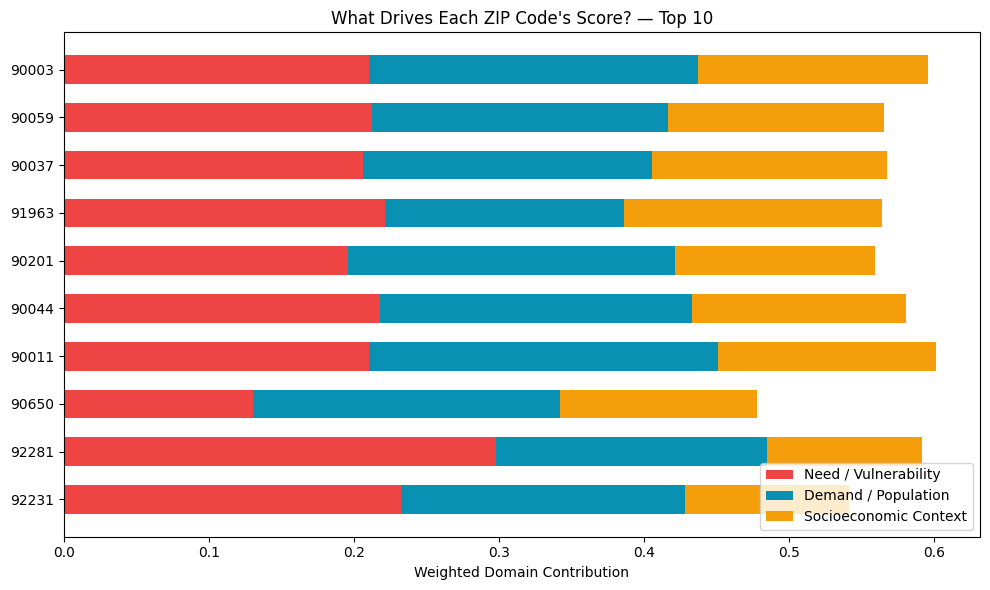

Chart saved → domain_breakdown.png ✓


In [13]:
if not PLOT:
    print("Install matplotlib to see charts.")
else:
    top10_zips  = result.head(10)["zip_code"].astype(int).tolist()
    domain_data = df.loc[df.index.isin(top10_zips),
                         ["need_score","demand_score","socioeconomic_score"]
                  ].reindex(top10_zips)
    domain_data.index = domain_data.index.astype(str)

    # Weight each domain sub-score by its configured weight
    w_need   = domain_data["need_score"]            * DOMAIN_WEIGHTS["need"]
    w_demand = domain_data["demand_score"]           * DOMAIN_WEIGHTS["demand"]
    w_soc    = domain_data["socioeconomic_score"]    * DOMAIN_WEIGHTS["socioeconomic"]

    fig, ax = plt.subplots(figsize=(10, 6))
    pos = np.arange(len(domain_data))
    bkw = dict(height=0.6)

    ax.barh(pos, w_need,   **bkw, color="#EF4444", label="Need / Vulnerability")
    ax.barh(pos, w_demand, **bkw, color="#0891B2",
            left=w_need, label="Demand / Population")
    ax.barh(pos, w_soc,    **bkw, color="#F59E0B",
            left=w_need + w_demand, label="Socioeconomic Context")

    ax.set_yticks(pos)
    ax.set_yticklabels(domain_data.index)
    ax.invert_yaxis()
    ax.set_xlabel("Weighted Domain Contribution")
    ax.set_title("What Drives Each ZIP Code's Score? — Top 10")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig("domain_breakdown.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Chart saved → domain_breakdown.png ✓")

## 12  |  Sensitivity Analysis
Re-run rankings under 3 weight schemes to check how stable the Top 10 is.

| Scenario | Need | Demand | Socioeconomic |
|---|---|---|---|
| Baseline | 0.45 | 0.30 | 0.25 |
| Need-heavy | 0.60 | 0.25 | 0.15 |
| Demand-heavy | 0.30 | 0.50 | 0.20 |

**Jaccard similarity** = size of intersection / size of union of two Top-10 sets  
(1.0 = identical rankings; 0.0 = no overlap)

In [14]:
scenarios = {
    "baseline":     {"need": 0.45, "demand": 0.30, "socioeconomic": 0.25},
    "need_heavy":   {"need": 0.60, "demand": 0.25, "socioeconomic": 0.15},
    "demand_heavy": {"need": 0.30, "demand": 0.50, "socioeconomic": 0.20},
}

top10_sets = {}
for name, weights in scenarios.items():
    alt = sum(
        weights[d] * df.get(f"{d}_score", pd.Series(0, index=df.index))
        for d in weights
    )
    alt = (alt - PENALTY_WEIGHT * df["clinic_density"]).clip(lower=0)
    top10_sets[name] = set(
        alt.sort_values(ascending=False).head(10).index.tolist()
    )

# ── Jaccard similarity matrix ─────────────────────────────────────────────────
names = list(top10_sets.keys())
print("── Jaccard Similarity (Top-10) ──────────────────────────────────────")
for i, a in enumerate(names):
    for b in names[i+1:]:
        inter   = len(top10_sets[a] & top10_sets[b])
        union   = len(top10_sets[a] | top10_sets[b])
        jaccard = inter / union if union else 0
        print(f"  {a:15s} vs {b:15s} : {jaccard:.2f}  ({inter}/10 ZIPs overlap)")

# ── Side-by-side Top-10 comparison ────────────────────────────────────────────
comparison = pd.DataFrame(
    {name: sorted(zips) for name, zips in top10_sets.items()}
)
print()
display(comparison)

── Jaccard Similarity (Top-10) ──────────────────────────────────────
  baseline        vs need_heavy      : 0.67  (8/10 ZIPs overlap)
  baseline        vs demand_heavy    : 0.67  (8/10 ZIPs overlap)
  need_heavy      vs demand_heavy    : 0.43  (6/10 ZIPs overlap)



,baseline,need_heavy,demand_heavy
0,90003,90003,90003
1,90037,90059,90037
2,90059,90650,90059
3,90650,91911,90201
4,91911,91963,90650
5,91963,92025,91744
6,92025,92105,91911
7,92105,92231,92025
8,92321,92276,92105
9,92571,92321,92571


## 13  |  Full Score Summary Statistics

In [15]:
# Distribution of expansion_index across all ranked ZIPs
print("── Score distribution ────────────────────────────────────────────────")
print(result["expansion_index"].describe().round(4).to_string())

# Breakdown by decile
result["decile"] = pd.qcut(result["expansion_index"], 10, labels=False) + 1
decile_stats = result.groupby("decile").agg(
    zip_count    = ("zip_code", "count"),
    avg_score    = ("expansion_index", "mean"),
    avg_poverty  = ("poverty_rate", "mean"),
    avg_pop      = ("population", "mean"),
).round(2)
print()
print("── Score decile breakdown (1 = lowest need, 10 = highest need) ──────")
display(decile_stats)

── Score distribution ────────────────────────────────────────────────
count    692.0000
mean       0.3755
std        0.2107
min        0.0000
25%        0.2187
50%        0.3588
75%        0.5264
max        1.0000

── Score decile breakdown (1 = lowest need, 10 = highest need) ──────


,zip_count,avg_score,avg_poverty,avg_pop
decile,,,,
1,70,0.04,6.95,13504.99
2,69,0.16,8.28,19631.96
3,69,0.22,8.27,24318.71
4,69,0.27,8.94,26604.30
5,69,0.33,10.89,29358.12
6,69,0.39,11.30,32986.16
7,69,0.45,12.96,37971.93
8,69,0.53,13.51,40347.68
9,69,0.61,18.75,38980.48
